## module 3b — constraint completion (masked discrete diffusion)

the autoregressive transformer (10) had two structural problems: it can only condition on
a *prefix* (so no "pin your toolbox plants anywhere, infill the rest"), and next-token
sampling can't count odd drifts. this swaps the generator for **masked discrete diffusion**
(absorbing-state, maskgit-style confidence scheduling — layoutdm's regime): a bidirectional
transformer sees the whole plan canvas, trains by predicting randomly-masked tokens, and
samples by iterative unmasking. pinned tokens are simply never masked — species-anywhere
infill for free. also adds **sun** as a site condition.

runtime: ~15-25 min on a small gpu (data ~5 min, training ~10-15 min). training is
checkpointed + resumable (`checkpoints/garden_maskdiff_{last,best}.pt`), so it's safe to
interrupt and re-run.

In [1]:
# get bvtrain (shared plumbing): locally it's ../bvtrain; on colab/kaggle clone the repo
import os, sys
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision")
sys.path[:0] = [p for p in _CANDS if os.path.isdir(f"{p}/bvtrain")]

import hashlib, json, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange

from bvtrain import garden as g

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.facecolor"] = "linen"
DEV

'cuda'

### canvas + tokens

fixed-length canvas instead of 08's variable sequence: 3 site tokens (bed w, d, sun) +
60 plant slots of (species, x, y), back-to-front, empty slots holding explicit
none-tokens. every position has a known token family, so sampling is grammar-masked by
construction.

In [2]:
NX, NY, NW, ND = 32, 12, 9, 7
MASK  = 0
T_W   = 1
T_D   = T_W + NW
T_SUN = T_D + ND
T_SP  = T_SUN + 3                       # idx 0 = empty slot
T_X   = T_SP + 1 + len(g.PALETTE)       # idx 0 = none
T_Y   = T_X + 1 + NX                    # idx 0 = none
VOCAB = T_Y + 1 + NY
MAXP  = 60
L     = 3 + 3 * MAXP

FAM = [(T_W, T_D), (T_D, T_SUN), (T_SUN, T_SP)] + [(T_SP, T_X), (T_X, T_Y), (T_Y, VOCAB)] * MAXP
FAM_MASK = torch.full((L, VOCAB), float("-inf"))
for p, (lo, hi) in enumerate(FAM):
    FAM_MASK[p, lo:hi] = 0
MASKABLE = torch.zeros(L, dtype=torch.bool); MASKABLE[3:] = True

def site_tokens(w, d, sun):
    return [T_W + min(NW - 1, int((w - 3.5) / 0.5)),
            T_D + min(ND - 1, int((d - 1.8) / 0.2)), T_SUN + sun]

def encode(plan, w, d, sun):
    t = site_tokens(w, d, sun)
    for i, x, y, r in sorted(plan, key=lambda p: (-p[2], p[1]))[:MAXP]:   # back-to-front
        t += [T_SP + 1 + i, T_X + 1 + min(NX - 1, int(x / w * NX)),
              T_Y + 1 + min(NY - 1, int(y / d * NY))]
    t += [T_SP, T_X, T_Y] * (MAXP - (len(t) - 3) // 3)
    return t

def decode(tokens, w, d):
    plan = []
    for k in range(3, L, 3):
        s, x, y = tokens[k] - T_SP, tokens[k + 1] - T_X, tokens[k + 2] - T_Y
        if s <= 0 or x <= 0 or y <= 0: continue
        i = s - 1
        plan.append((i, (x - 0.5) / NX * w, (y - 0.5) / NY * d, g.PALETTE[i]["s"] / 200))
    return plan

In [3]:
N_TRAIN, N_VAL = 12000, 500
sites = [g.rand_site() for _ in range(N_TRAIN + N_VAL)]
X = torch.tensor([encode(g.gen_plan(w, d, s), w, d, s)
                  for w, d, s in tqdm(sites, desc="rule plans")])
Xtr, Xval = X[:N_TRAIN], X[N_TRAIN:]
Xtr.shape, Xval.shape

rule plans:   0%|          | 0/12500 [00:00<?, ?it/s]

(torch.Size([12000, 183]), torch.Size([500, 183]))

In [4]:
class LayoutMDM(nn.Module):
    def __init__(self, v=VOCAB, dm=192, heads=6, layers=6, ctx=L):
        super().__init__()
        self.tok = nn.Embedding(v, dm); self.pos = nn.Embedding(ctx, dm)
        blk = nn.TransformerEncoderLayer(dm, heads, dm * 4, dropout=0.1,
                                         batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(blk, layers, enable_nested_tensor=False)
        self.head = nn.Linear(dm, v)
    def forward(self, x):
        h = self.tok(x) + self.pos(torch.arange(x.shape[1], device=x.device))
        return self.head(self.tf(h))        # bidirectional — no causal mask

model = LayoutMDM().to(DEV)
sum(p.numel() for p in model.parameters())

2736275

### training

maskgit objective: per plan, draw a masking ratio from the cosine schedule, hide that
fraction of plant tokens (site tokens always visible), predict the hidden ones. resumes
automatically from `_last.pt` when the config signature matches; `FRESH = True` forces a
restart.

In [5]:
EPOCHS = 40
FRESH = False
CFG = dict(n=N_TRAIN, epochs=EPOCHS, dm=192, layers=6, seed=SEED, vocab=VOCAB, maxp=MAXP)
SIG = hashlib.md5(json.dumps(CFG, sort_keys=True).encode()).hexdigest()[:10]
LAST, BEST = g.ckpt_dir() / "garden_maskdiff_last.pt", g.ckpt_dir() / "garden_maskdiff_best.pt"

opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
start_ep, best_val, hist = 0, float("inf"), {"train": [], "val": []}
if LAST.exists() and not FRESH:
    ck = torch.load(LAST, map_location=DEV, weights_only=False)
    if ck.get("sig") == SIG:
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        start_ep, best_val, hist = ck["epoch"], ck["best_val"], ck["hist"]
        print(f"resumed at epoch {start_ep} (best val {best_val:.3f})")
    else:
        print("config changed — starting fresh")

In [6]:
def masked_batch(xb, gen=None):
    B = xb.shape[0]
    ratio = torch.cos(torch.rand(B, 1, generator=gen) * math.pi / 2).clamp(min=0.05)
    m = (torch.rand(B, L, generator=gen) < ratio) & MASKABLE
    xin = xb.clone(); xin[m] = MASK
    return xin, m

loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtr), batch_size=64, shuffle=True)
vloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xval), batch_size=256)

for ep in range(start_ep, EPOCHS):
    model.train(); tot = n = 0
    bar = tqdm(loader, desc=f"epoch {ep + 1}/{EPOCHS}", leave=False)
    for (xb,) in bar:
        xin, m = masked_batch(xb)
        loss = F.cross_entropy(model(xin.to(DEV))[m.to(DEV)], xb.to(DEV)[m.to(DEV)])
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); n += 1
        bar.set_postfix(loss=f"{tot / n:.3f}")
    model.eval(); vgen = torch.Generator().manual_seed(123); vtot = vn = 0
    with torch.no_grad():
        for (xb,) in vloader:
            xin, m = masked_batch(xb, vgen)
            vtot += F.cross_entropy(model(xin.to(DEV))[m.to(DEV)], xb.to(DEV)[m.to(DEV)]).item()
            vn += 1
    tr, vl = tot / n, vtot / vn
    hist["train"].append(tr); hist["val"].append(vl)
    star = ""
    if vl < best_val:
        best_val, star = vl, " *"
        torch.save({"sig": SIG, "model": model.state_dict(), "val": vl}, BEST)
    torch.save({"sig": SIG, "model": model.state_dict(), "opt": opt.state_dict(),
                "epoch": ep + 1, "best_val": best_val, "hist": hist}, LAST)
    print(f"epoch {ep + 1:2d}  train {tr:.3f}  val {vl:.3f}{star}")

epoch 1/40:   0%|          | 0/188 [00:00<?, ?it/s]

C:\Users\daniel\anaconda3\lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


epoch  1  train 1.630  val 1.163 *


epoch 2/40:   0%|          | 0/188 [00:00<?, ?it/s]

epoch  2  train 1.158  val 1.096 *


...

epoch 38  train 0.965  val 0.950 *


epoch 39/40:   0%|          | 0/188 [00:00<?, ?it/s]

epoch 39  train 0.964  val 0.953


epoch 40/40:   0%|          | 0/188 [00:00<?, ?it/s]

epoch 40  train 0.964  val 0.949 *


using best checkpoint (val 0.949)


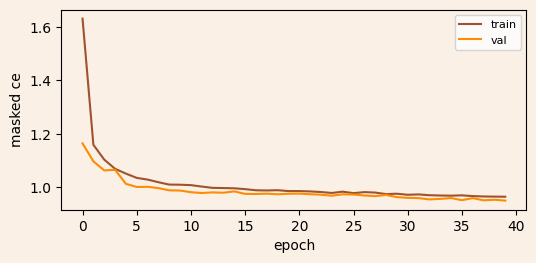

In [7]:
ck = torch.load(BEST, map_location=DEV, weights_only=False)
model.load_state_dict(ck["model"]); model.eval()
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.set_facecolor("linen")
ax.plot(hist["train"], color="sienna", label="train")
ax.plot(hist["val"], color="darkorange", label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("masked ce"); ax.legend(fontsize=8)
print(f"using best checkpoint (val {ck['val']:.3f})")

### sampling — iterative unmasking

start with everything masked except the site (and any pins), predict all positions,
keep the most confident, re-mask the rest on a cosine schedule, repeat. 12 forward
passes per plan, batched across plans.

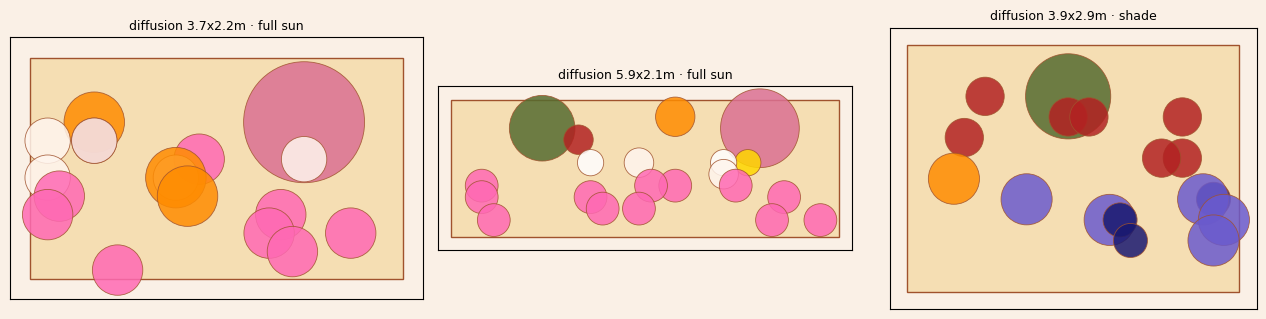

In [8]:
FAM_DEV = FAM_MASK.to(DEV)

@torch.no_grad()
def sample_plans(plan_sites, steps=12, temp=1.0, pins=None):
    B = len(plan_sites)
    canvas = torch.zeros(B, L, dtype=torch.long)
    fixed = torch.zeros(B, L, dtype=torch.bool)
    nonone = torch.zeros(B, L, dtype=torch.bool)      # pinned slots must get real x/y
    for b, (w, d, sun) in enumerate(plan_sites):
        canvas[b, :3] = torch.tensor(site_tokens(w, d, sun)); fixed[b, :3] = True
        for p, tok in (pins[b] if pins else {}).items():
            canvas[b, p] = tok; fixed[b, p] = True
            if (p - 3) % 3 == 0:                      # species pin → x/y can't be none
                nonone[b, p + 1] = nonone[b, p + 2] = True
    canvas, fixed, nonone = canvas.to(DEV), fixed.to(DEV), nonone.to(DEV)
    canvas[~fixed] = MASK
    M0 = (canvas == MASK).sum(1)
    for t in range(steps):
        logits = model(canvas) + FAM_DEV
        logits[..., T_X] = logits[..., T_X].masked_fill(nonone, float("-inf"))
        logits[..., T_Y] = logits[..., T_Y].masked_fill(nonone, float("-inf"))
        probs = F.softmax(logits / temp, -1)
        samp = torch.multinomial(probs.reshape(-1, VOCAB), 1).reshape(B, L)
        conf = probs.gather(-1, samp.unsqueeze(-1)).squeeze(-1)
        still = canvas == MASK
        canvas = torch.where(still, samp, canvas)
        n_mask = (M0.float() * math.cos(math.pi / 2 * (t + 1) / steps)).long()
        conf = conf.masked_fill(~still, float("inf"))
        for b in range(B):
            if n_mask[b] > 0:
                canvas[b, conf[b].argsort()[:n_mask[b]]] = MASK
    return [decode(canvas[b].tolist(), s[0], s[1]) for b, s in enumerate(plan_sites)]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
demo_sites = [g.rand_site() for _ in range(3)]
for ax, (site, plan) in zip(axes, zip(demo_sites, sample_plans(demo_sites))):
    g.show_plan(plan, site[0], site[1], ax,
                f"diffusion {site[0]}x{site[1]}m · {g.SUN_NAMES[site[2]]}")
plt.tight_layout()

### toolbox completion

the compose interaction: the user pins species from their toolbox (here 2 hydrangea +
5 echinacea, positions left to the model), the model infills placement and companions.
pinned tokens are never re-masked, so the pins survive by construction — three
completions of the same brief, pinned species outlined in black.

[(2, 9), (2, 9), (2, 9)]

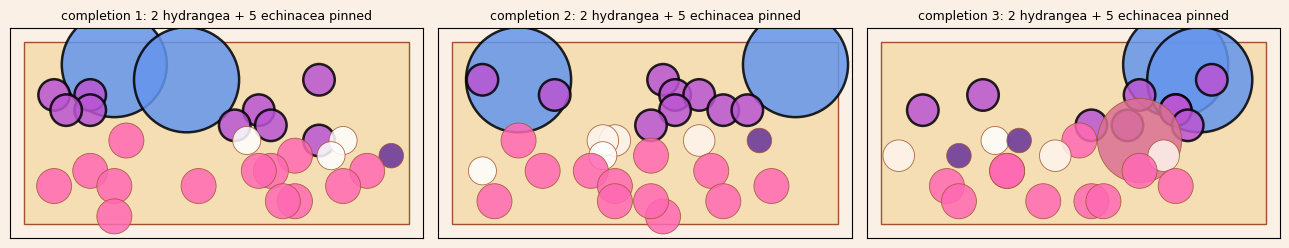

In [9]:
HYD = next(i for i, p in enumerate(g.PALETTE) if "Hydrangea" in p["name"])
ECH = next(i for i, p in enumerate(g.PALETTE) if "Echinacea" in p["name"])
pin = {3 + s * 3: T_SP + 1 + HYD for s in (0, 1)}
pin |= {3 + s * 3: T_SP + 1 + ECH for s in (6, 7, 8, 9, 10)}
site = (5.5, 2.6, 2)

plans = sample_plans([site] * 3, pins=[pin] * 3)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for k, (ax, plan) in enumerate(zip(axes, plans)):
    hl = [j for j, (i, *_) in enumerate(plan) if i in (HYD, ECH)]
    g.show_plan(plan, site[0], site[1], ax, f"completion {k + 1}: 2 hydrangea + 5 echinacea pinned", pins=hl)
plt.tight_layout()
[(sum(1 for i, *_ in p if i == HYD), sum(1 for i, *_ in p if i == ECH)) for p in plans]

rules:   0%|          | 0/100 [00:00<?, ?it/s]

,random,rules,diffusion
overlap,0.949,1.000,0.950
height,0.703,0.985,0.975
cover,0.637,0.697,0.620
drift,0.211,0.891,0.345
sun,0.797,1.000,1.000
score,0.659,0.915,0.778


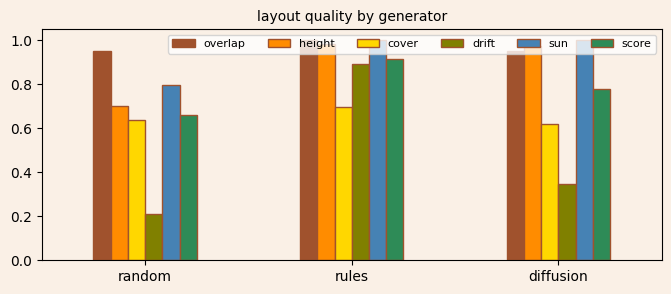

In [10]:
eval_sites = [g.rand_site() for _ in range(100)]

def score_plans(plans):
    return pd.DataFrame([g.score(p, w, d, s)
                         for p, (w, d, s) in zip(plans, eval_sites)]).mean().round(3)

results = pd.DataFrame({
    "random": score_plans([g.gen_random(w, d) for w, d, s in eval_sites]),
    "rules": score_plans([g.gen_plan(w, d, s) for w, d, s in tqdm(eval_sites, desc="rules", leave=False)]),
    "diffusion": score_plans(sample_plans(eval_sites)),
})
ax = results.T[["overlap", "height", "cover", "drift", "sun", "score"]].plot.bar(
    color=["sienna", "darkorange", "gold", "olive", "steelblue", "seagreen"],
    figsize=(8, 3), rot=0, edgecolor="sienna")
ax.set_facecolor("linen"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncols=6); ax.set_title("layout quality by generator", fontsize=10)
results

### takeaways

- pins survive by construction (2/2 hydrangea, and the 5 pinned echinacea get completed
  to an odd 9), and **sun compliance is perfect (1.000 vs random 0.797)** — site
  conditioning works.
- overall 0.778 beats the autoregressive 0.758, with bidirectional context nearly matching
  the rules on height order (0.975). drift parity is still unsolved (0.345): confidence-
  scheduled unmasking doesn't count either. next lever: explicit per-species count tokens
  in the canvas, or drift-aware resampling at decode time.
- `12_render_plan` turns any of these plans into a styled image via seg-controlnet.